# Classificador de Textos: Humano vs IA
### DistilBERT fine-tuned — OpenAI, Meta, Google, Anthropic, Humano

## Celula 1 - Instalacao

In [ ]:
!pip uninstall datasets evaluate -y
!pip install transformers==4.40.0 tokenizers==0.19.0 scikit-learn pandas numpy torch matplotlib seaborn accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 26.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6


## Celula 2 - Diagnostico

In [1]:
import sys
print('Python:', sys.executable)
import torch
print('PyTorch:', torch.__version__)
import transformers
print('Transformers:', transformers.__version__)
from transformers.utils import is_torch_available
print('PyTorch visivel para Transformers:', is_torch_available())
print('GPU disponivel:', torch.cuda.is_available())

Python: /usr/bin/python3
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
PyTorch visivel para Transformers: True
GPU disponivel: True


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/beatrizsilva23/dados-v2/dataset_final_atualizado_comMETA.csv
/kaggle/input/datasets/beatrizsilva23/subm-2/subm2_labels_revealed.csv
/kaggle/input/datasets/beatrizsilva23/subm-3/subm3.csv
/kaggle/input/datasets/beatrizsilva23/meus-dados/subm1_labels_revealed.csv
/kaggle/input/datasets/beatrizsilva23/meus-dados/dataset-exemplos.csv
/kaggle/input/datasets/beatrizsilva23/meus-dados/dataset_completo.csv
/kaggle/input/datasets/beatrizsilva23/meus-dados/subm2.csv


## Celula 3 - Imports

In [3]:
import os
import re
import pickle
import unicodedata
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    get_cosine_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Imports OK!')


Imports OK!


## Celula 4 - Configuracoes

In [17]:
SEED          = 42
MAX_LENGTH    = 128
BATCH_SIZE    = 64
EPOCHS        = 6
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
DROPOUT       = 0.3
MODEL_NAME    = 'distilbert-base-uncased'
PATIENCE      = 3
NUM_LABELS    = 5

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## Celula 5 - Funcoes de limpeza

In [5]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s.,!?;:\'-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_light(text):
    text = str(text)
    text = unicodedata.normalize('NFKC', text)
    replacements = {
        '\u2018': "'", '\u2019': "'",
        '\u201c': '"', '\u201d': '"',
        '\u2013': '-', '\u2014': '-',
        '\u00a0': ' ',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', ' ', text)
    text = re.sub(r'\r\n?', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

def strip_json_edge_artifacts(text):
    text = str(text).strip()
    edge_chars = set('"\' ()[]{}')
    while text and text[0] in edge_chars:
        text = text[1:].lstrip()
    while text and text[-1] in edge_chars:
        text = text[:-1].rstrip()
    return text

print('Funcoes de limpeza OK!')

Funcoes de limpeza OK!


## Celula 6 - Carregar e preparar dados de treino

In [6]:
import pandas as pd

# Carrega os 3 ficheiros
df_subm1 = pd.read_csv('/kaggle/input/datasets/beatrizsilva23/meus-dados/subm1_labels_revealed.csv', sep=';', encoding='utf-8-sig', engine='python', on_bad_lines='skip')  # <- muda o caminho
df_subm2 = pd.read_csv('/kaggle/input/datasets/beatrizsilva23/subm-2/subm2_labels_revealed.csv', sep=';', encoding='utf-8-sig', engine='python', on_bad_lines='skip')  # <- muda o caminho
df_subm3 = pd.read_csv('/kaggle/input/datasets/beatrizsilva23/subm-3/subm3.csv', sep=';')

# Junta subm1 e subm2
df_12 = pd.concat([df_subm1, df_subm2], ignore_index=True)

ids_12    = set(df_12['ID'].tolist())
ids_subm3 = set(df_subm3['ID'].tolist())

print(f'IDs em subm1+2:    {len(ids_12)}')
print(f'IDs em subm3:      {len(ids_subm3)}')
print(f'IDs em comum:      {len(ids_12 & ids_subm3)}')
print(f'IDs so em subm1+2: {len(ids_12 - ids_subm3)}')
print(f'IDs so em subm3:   {len(ids_subm3 - ids_12)}')

IDs em subm1+2:    200
IDs em subm3:      150
IDs em comum:      0
IDs so em subm1+2: 200
IDs so em subm3:   150


In [18]:
DATA_PATH = '/kaggle/input/datasets/beatrizsilva23/meus-dados/dataset_completo.csv'
df = pd.read_csv(DATA_PATH, sep=',')
print(f'Dataset: {df.shape[0]} exemplos')
print('\nDistribuicao das classes:')
print(df['model'].value_counts())

df['content'] = df['content'].apply(clean_text)
df = df[df['content'].str.len() > 10].reset_index(drop=True)

# Sampling
N_TOTAL = 50000
N_HUMAN = N_TOTAL // 3
N_OTHER = N_TOTAL - N_HUMAN

df_human = df[df['model'] == 'Human']
df_other = df[df['model'] != 'Human']

df_human_sample   = df_human.sample(n=N_HUMAN, random_state=SEED)
class_counts      = df_other['model'].value_counts()
proportions       = class_counts / class_counts.sum()
samples_per_class = (proportions * N_OTHER).astype(int)

df_other_sample = pd.concat([
    df_other[df_other['model'] == cls].sample(n=min(n, len(df_other[df_other['model'] == cls])), random_state=SEED)
    for cls, n in samples_per_class.items()
])

df_sampled = pd.concat([df_human_sample, df_other_sample]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'\nApos sampling:')
print(df_sampled['model'].value_counts())
print(f'Total: {len(df_sampled)}')

# ADICIONAR DADOS DO PROFESSOR 1
df_prof1 = pd.read_csv('/kaggle/input/datasets/beatrizsilva23/meus-dados/subm1_labels_revealed.csv', sep=';', encoding='utf-8-sig', engine='python', on_bad_lines='skip')  # <- muda o caminho
df_prof1 = df_prof1.rename(columns={'Text': 'content', 'Label': 'model'})
df_prof1 = df_prof1[['content', 'model']]
df_prof1['content'] = df_prof1['content'].apply(clean_text)
df_prof1 = df_prof1[df_prof1['content'].str.len() > 10].reset_index(drop=True)
print(f'\nDados professor 1: {len(df_prof1)} linhas')
print(df_prof1['model'].value_counts())

# ADICIONAR DADOS DO PROFESSOR 2
df_prof2 = pd.read_csv('/kaggle/input/datasets/beatrizsilva23/subm-2/subm2_labels_revealed.csv', sep=';', encoding='utf-8-sig', engine='python', on_bad_lines='skip')  # <- muda o caminho
df_prof2 = df_prof2.rename(columns={'Text': 'content', 'Label': 'model'})
df_prof2 = df_prof2[['content', 'model']]
df_prof2['content'] = df_prof2['content'].apply(clean_text)
df_prof2 = df_prof2[df_prof2['content'].str.len() > 10].reset_index(drop=True)
print(f'\nDados professor 2: {len(df_prof2)} linhas')
print(df_prof2['model'].value_counts())

# Juntar tudo
df_sampled = pd.concat([df_sampled, df_prof1], ignore_index=True)
df_sampled = df_sampled.drop_duplicates(subset='content').reset_index(drop=True)
print(f'\nTotal apos adicionar dados do professor: {len(df_sampled)}')
print(df_sampled['model'].value_counts())

# Encoding de labels
le = LabelEncoder()
df_sampled['label'] = le.fit_transform(df_sampled['model'])
print('\nMapeamento:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx} -> {cls}')

# Split
train_df, temp_df = train_test_split(df_sampled, test_size=0.30, stratify=df_sampled['label'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
print(f'\nTreino: {len(train_df)} | Validacao: {len(val_df)} | Teste: {len(test_df)}')

Dataset: 100267 exemplos

Distribuicao das classes:
model
Human        29830
OpenAI       21141
Google       16786
Meta         16606
Anthropic    15904
Name: count, dtype: int64

Apos sampling:
model
Human        16666
OpenAI       10004
Google        7943
Meta          7858
Anthropic     7526
Name: count, dtype: int64
Total: 49997

Dados professor 1: 100 linhas
model
Human        34
Meta         18
Anthropic    17
Google       17
OpenAI       14
Name: count, dtype: int64

Dados professor 2: 100 linhas
model
Human        34
Google       18
OpenAI       16
Anthropic    16
Meta         16
Name: count, dtype: int64

Total apos adicionar dados do professor: 50092
model
Human        16697
OpenAI       10017
Google        7960
Meta          7876
Anthropic     7542
Name: count, dtype: int64

Mapeamento:
  0 -> Anthropic
  1 -> Google
  2 -> Human
  3 -> Meta
  4 -> OpenAI

Treino: 35064 | Validacao: 7514 | Teste: 7514


## Celula 7 - Dataset PyTorch e Tokenizer

In [19]:
# FEATURES ESTILISTICAS 

def extract_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.zeros(12, dtype=np.float32)
    words     = text.split()
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if s.strip()]
    n_words   = max(len(words), 1)
    n_sents   = max(len(sentences), 1)
    sent_lens = [len(s.split()) for s in sentences]
    return np.array([
        len(words),                                              # num palavras
        len(sentences),                                          # num frases
        len(words) / n_sents,                                    # palavras por frase
        len(set(words)) / n_words,                              # riqueza vocabular
        np.mean([len(w) for w in words]),                       # comprimento medio palavra
        np.std(sent_lens) if len(sent_lens) > 1 else 0,         # burstiness (irregularidade)
        text.count(',') / n_words,                              # virgulas por palavra
        text.count(';') / n_words,                              # ponto e virgula
        text.count('(') / n_words,                              # parenteses
        sum(1 for w in words if w[0].isupper()) / n_words,      # palavras com maiuscula
        len(re.findall(r'\d+', text)) / n_words,                # densidade de numeros
        sum(1 for s in sentences if len(s.split()) > 20) / n_sents,  # frases longas
    ], dtype=np.float32)

# Calcula features para treino, val e teste
print('A calcular features estilisticas...')
train_feats = np.vstack(train_df['content'].apply(extract_features).values)
val_feats   = np.vstack(val_df['content'].apply(extract_features).values)
test_feats  = np.vstack(test_df['content'].apply(extract_features).values)

# Normaliza as features
scaler      = StandardScaler()
train_feats = scaler.fit_transform(train_feats).astype(np.float32)
val_feats   = scaler.transform(val_feats).astype(np.float32)
test_feats  = scaler.transform(test_feats).astype(np.float32)
print(f'Features shape: {train_feats.shape}')

# Dataset hibrido: texto + features estilisticas
class HybridDataset(Dataset):
    def __init__(self, texts, labels, feats, tokenizer, max_length=MAX_LENGTH):
        encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )
        self.input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long)
        self.attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long)
        self.labels         = torch.tensor(list(labels),                dtype=torch.long)
        self.feats          = torch.tensor(feats,                       dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx],
            'feats':          self.feats[idx],
        }

print('A carregar tokenizer...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print('A criar datasets...')
train_dataset = HybridDataset(train_df['content'], train_df['label'], train_feats, tokenizer)
val_dataset   = HybridDataset(val_df['content'],   val_df['label'],   val_feats,   tokenizer)
test_dataset  = HybridDataset(test_df['content'],  test_df['label'],  test_feats,  tokenizer)
print('Datasets criados!')


A calcular features estilisticas...
Features shape: (35064, 12)
A carregar tokenizer...
A criar datasets...
Datasets criados!


## Celula 8 - Construir modelo

In [20]:
# MODELO HIBRIDO: DistilBERT + features estilisticasFEAT_DIM = 12  # numero de features estilisticas

class HybridClassifier(nn.Module):
    def __init__(self, num_classes=NUM_LABELS, feat_dim=FEAT_DIM, dropout=DROPOUT):
        super().__init__()
        self.bert    = DistilBertModel.from_pretrained(MODEL_NAME)
        bert_dim     = self.bert.config.hidden_size  # 768

        # Camada para processar features estilisticas
        self.feat_net = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Classificador final: BERT [CLS] + features estilisticas
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(bert_dim + 32, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_ids, attention_mask, feats):
        # Embedding BERT — usa o token [CLS]
        bert_out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embed = bert_out.last_hidden_state[:, 0, :]  # [batch, 768]

        # Features estilisticas
        feat_embed = self.feat_net(feats)  # [batch, 32]

        # Junta e classifica
        combined = torch.cat([cls_embed, feat_embed], dim=1)  # [batch, 800]
        return self.classifier(combined)

model     = HybridClassifier().to(device)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totais:     {total:,}')
print(f'Parametros treinaveis: {trainable:,}')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parametros totais:     66,572,133
Parametros treinaveis: 66,572,133


## Celula 9 - Treino

In [21]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

criterion    = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer    = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1    = -1
patience_count = 0
best_state     = None

print('=' * 60)
print('A iniciar treino (modelo hibrido DistilBERT + features)...')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss       = 0.0
    train_preds_all  = []
    train_labels_all = []

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        feats          = batch['feats'].to(device)
        logits         = model(input_ids=input_ids, attention_mask=attention_mask, feats=feats)
        loss           = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        train_preds_all.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = accuracy_score(train_labels_all, train_preds_all)

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            feats          = batch['feats'].to(device)
            logits         = model(input_ids=input_ids, attention_mask=attention_mask, feats=feats)
            loss           = criterion(logits, labels)
            val_loss      += loss.item()
            preds          = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = accuracy_score(all_labels, all_preds)
    val_f1       = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_val_f1 + 0.001:
        best_val_f1    = val_f1
        patience_count = 0
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  -> Melhor modelo guardado (F1={best_val_f1:.4f})')
    else:
        patience_count += 1
        print(f'  -> Sem melhoria ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'Early stopping na epoch {epoch}')
            break

model.load_state_dict(best_state)
print('\nTreino concluido!')


A iniciar treino (modelo hibrido DistilBERT + features)...
Epoch 01/4 | Train Loss: 0.7548 | Train Acc: 0.8050 | Val Loss: 0.4616 | Val Acc: 0.9683 | Val F1: 0.9657
  -> Melhor modelo guardado (F1=0.9657)
Epoch 02/4 | Train Loss: 0.4506 | Train Acc: 0.9754 | Val Loss: 0.4520 | Val Acc: 0.9734 | Val F1: 0.9706
  -> Melhor modelo guardado (F1=0.9706)
Epoch 03/4 | Train Loss: 0.4208 | Train Acc: 0.9898 | Val Loss: 0.4309 | Val Acc: 0.9834 | Val F1: 0.9824
  -> Melhor modelo guardado (F1=0.9824)
Epoch 04/4 | Train Loss: 0.4093 | Train Acc: 0.9953 | Val Loss: 0.4340 | Val Acc: 0.9824 | Val F1: 0.9814
  -> Sem melhoria (1/3)

Treino concluido!


## Celula 10 - Guardar modelo e tokenizer

In [23]:
import pickle

os.makedirs('./best_model', exist_ok=True)
torch.save(model.state_dict(), './best_model/hybrid_model.pth')
tokenizer.save_pretrained('./best_model')

with open('./best_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open('./best_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Modelo guardado em: ./best_model')
print('Ficheiros:')
for fname in os.listdir('./best_model'):
    print(f'  {fname}')


Modelo guardado em: ./best_model
Ficheiros:
  tokenizer_config.json
  label_encoder.pkl
  tokenizer.json
  scaler.pkl
  hybrid_model.pth


## Celula 11 - Avaliacao no conjunto de teste

In [24]:
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        feats          = batch['feats'].to(device)
        logits         = model(input_ids=input_ids, attention_mask=attention_mask, feats=feats)
        preds          = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('Relatorio de Classificacao (conjunto de teste):')
print(classification_report(all_labels, all_preds, target_names=le.classes_, digits=4))


Relatorio de Classificacao (conjunto de teste):
              precision    recall  f1-score   support

   Anthropic     0.9785    0.9629    0.9706      1132
      Google     0.9841    0.9824    0.9832      1194
       Human     0.9865    0.9916    0.9890      2504
        Meta     0.9873    0.9848    0.9860      1182
      OpenAI     0.9683    0.9747    0.9715      1502

    accuracy                         0.9814      7514
   macro avg     0.9809    0.9793    0.9801      7514
weighted avg     0.9814    0.9814    0.9814      7514



## Celula 12 - Matriz de confusao

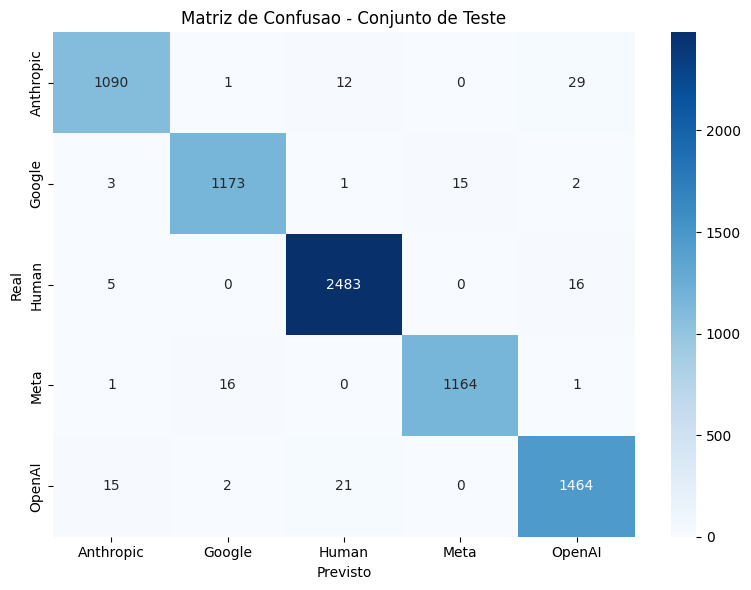

In [25]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusao - Conjunto de Teste')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Celula 13 - Curvas de treino

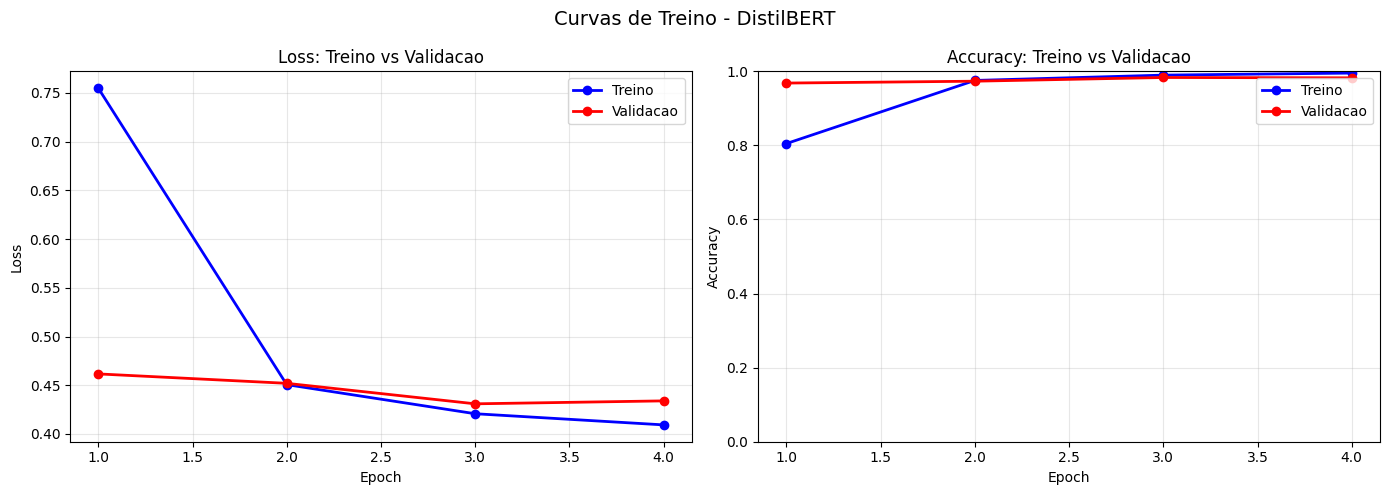

In [26]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss treino vs validacao
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Treino',    linewidth=2, markersize=6)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Validacao', linewidth=2, markersize=6)
axes[0].set_title('Loss: Treino vs Validacao')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Accuracy treino vs validacao
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Treino',    linewidth=2, markersize=6)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Validacao', linewidth=2, markersize=6)
axes[1].set_title('Accuracy: Treino vs Validacao')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Treino - DistilBERT', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Celula 14 - Carregar modelo guardado (sessao nova)

In [ ]:

# model     = DistilBertForSequenceClassification.from_pretrained('./best_model').to(device)
# tokenizer = DistilBertTokenizerFast.from_pretrained('./best_model')
# with open('./best_model/label_encoder.pkl', 'rb') as f:
#     le = pickle.load(f)

# print('Modelo carregado!')
# print('Classes:', list(le.classes_))

print('Para carregar o modelo numa sessao nova, descomentar as linhas acima.')

## Celula 15 - Previsoes nos dados de exemplo
### Ficheiro CSV com colunas: ID, Text, Label (Label e opcional)

In [27]:
EXEMPLOS_PATH = '/kaggle/input/datasets/beatrizsilva23/meus-dados/dataset-exemplos.csv'
EXEMPLOS_SEP  = ';'

dados_exemplo = pd.read_csv(EXEMPLOS_PATH, sep=EXEMPLOS_SEP)
print(f'Dados de exemplo: {len(dados_exemplo)} linhas')

# Limpeza
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text_light)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(strip_json_edge_artifacts)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text)

# Features estilisticas
ex_feats = np.vstack(dados_exemplo['Text'].apply(extract_features).values)
ex_feats = scaler.transform(ex_feats).astype(np.float32)

# Tokenizar
encodings = tokenizer(
    list(dados_exemplo['Text']),
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
)
input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long).to(device)
attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long).to(device)
feats_tensor   = torch.tensor(ex_feats,                   dtype=torch.float32).to(device)

# Previsoes
model.eval()
previsoes      = []
probabilidades = []

with torch.no_grad():
    for i in range(0, len(input_ids), BATCH_SIZE):
        batch_ids   = input_ids[i:i+BATCH_SIZE]
        batch_mask  = attention_mask[i:i+BATCH_SIZE]
        batch_feats = feats_tensor[i:i+BATCH_SIZE]
        logits      = model(input_ids=batch_ids, attention_mask=batch_mask, feats=batch_feats)
        probs       = torch.softmax(logits, dim=-1)
        preds       = torch.argmax(probs, dim=-1)
        for pred, prob in zip(preds.cpu().numpy(), probs.cpu().numpy()):
            previsoes.append(le.classes_[pred])
            probabilidades.append({le.classes_[j]: round(float(prob[j]), 4) for j in range(len(le.classes_))})

dados_exemplo['Previsao'] = previsoes

if 'Label' in dados_exemplo.columns:
    correct = (dados_exemplo['Label'] == dados_exemplo['Previsao']).sum()
    total   = len(dados_exemplo)
    print(f'\nAccuracy: {correct/total:.4f} ({correct}/{total} corretos)')
    print('\nRelatorio de Classificacao:')
    print(classification_report(dados_exemplo['Label'], dados_exemplo['Previsao'], digits=4))
    print('\nAccuracy por classe:')
    for classe in sorted(dados_exemplo['Label'].unique()):
        mask = dados_exemplo['Label'] == classe
        c    = (dados_exemplo.loc[mask, 'Label'] == dados_exemplo.loc[mask, 'Previsao']).sum()
        t    = mask.sum()
        print(f'  {classe:<12}: {c/t:.4f} ({c}/{t})')

cols = ['ID', 'Label', 'Previsao'] if 'Label' in dados_exemplo.columns else ['ID', 'Previsao']
print('\nResultados:')
print(dados_exemplo[cols].to_string(index=False))


Dados de exemplo: 125 linhas

Accuracy: 0.5200 (65/125 corretos)

Relatorio de Classificacao:
              precision    recall  f1-score   support

   Anthropic     0.3774    0.8696    0.5263        23
      Google     0.0000    0.0000    0.0000        16
       Human     0.6290    0.7500    0.6842        52
        Meta     0.0000    0.0000    0.0000        17
      OpenAI     0.6000    0.3529    0.4444        17

    accuracy                         0.5200       125
   macro avg     0.3213    0.3945    0.3310       125
weighted avg     0.4127    0.5200    0.4419       125


Accuracy por classe:
  Anthropic   : 0.8696 (20/23)
  Google      : 0.0000 (0/16)
  Human       : 0.7500 (39/52)
  Meta        : 0.0000 (0/17)
  OpenAI      : 0.3529 (6/17)

Resultados:
    ID     Label  Previsao
  D1-1     Human     Human
  D1-2      Meta     Human
  D1-3    Google Anthropic
  D1-4      Meta Anthropic
  D1-5     Human Anthropic
  D1-6    Google     Human
  D1-7    OpenAI Anthropic
  D1-8      Me

Dados de exemplo: 125 linhas

Accuracy: 0.6240 (78/125 corretos)

Relatorio de Classificacao:
              precision    recall  f1-score   support

   Anthropic     0.4318    0.8261    0.5672        23
      Google     1.0000    0.5625    0.7200        16
       Human     0.8571    0.6923    0.7660        52
        Meta     0.8333    0.2941    0.4348        17
      OpenAI     0.3750    0.5294    0.4390        17

    accuracy                         0.6240       125
   macro avg     0.6995    0.5809    0.5854       125
weighted avg     0.7284    0.6240    0.6340       125


Accuracy por classe:
  Anthropic   : 0.8261 (19/23)
  Google      : 0.5625 (9/16)
  Human       : 0.6923 (36/52)
  Meta        : 0.2941 (5/17)
  OpenAI      : 0.5294 (9/17)

Resultados:
    ID     Label  Previsao
  D1-1     Human     Human
  D1-2      Meta    OpenAI
  D1-3    Google    OpenAI
  D1-4      Meta      Meta
  D1-5     Human    OpenAI
  D1-6    Google    Google
  D1-7    OpenAI Anthropic
  D1-8      Me

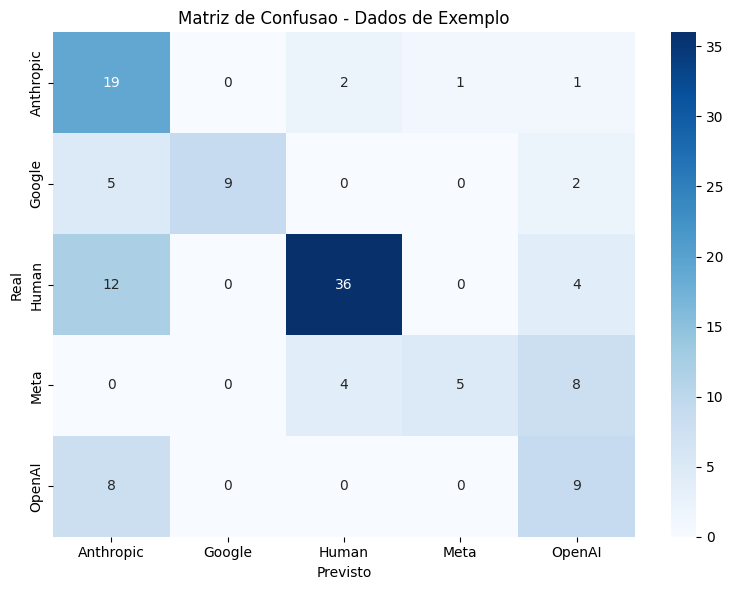

In [15]:
EXEMPLOS_PATH = '/kaggle/input/datasets/beatrizsilva23/meus-dados/dataset-exemplos.csv'
EXEMPLOS_SEP  = ';'

dados_exemplo = pd.read_csv(EXEMPLOS_PATH, sep=EXEMPLOS_SEP)
print(f'Dados de exemplo: {len(dados_exemplo)} linhas')

# Limpeza
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text_light)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(strip_json_edge_artifacts)
dados_exemplo['Text'] = dados_exemplo['Text'].apply(clean_text)

# Features estilisticas
ex_feats = np.vstack(dados_exemplo['Text'].apply(extract_features).values)
ex_feats = scaler.transform(ex_feats).astype(np.float32)

# Tokenizar
encodings = tokenizer(
    list(dados_exemplo['Text']),
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
)
input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long).to(device)
attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long).to(device)
feats_tensor   = torch.tensor(ex_feats,                   dtype=torch.float32).to(device)

# Previsoes
model.eval()
previsoes      = []
probabilidades = []

with torch.no_grad():
    for i in range(0, len(input_ids), BATCH_SIZE):
        batch_ids   = input_ids[i:i+BATCH_SIZE]
        batch_mask  = attention_mask[i:i+BATCH_SIZE]
        batch_feats = feats_tensor[i:i+BATCH_SIZE]
        logits      = model(input_ids=batch_ids, attention_mask=batch_mask, feats=batch_feats)
        probs       = torch.softmax(logits, dim=-1)
        preds       = torch.argmax(probs, dim=-1)
        for pred, prob in zip(preds.cpu().numpy(), probs.cpu().numpy()):
            previsoes.append(le.classes_[pred])
            probabilidades.append({le.classes_[j]: round(float(prob[j]), 4) for j in range(len(le.classes_))})

dados_exemplo['Previsao'] = previsoes

if 'Label' in dados_exemplo.columns:
    correct = (dados_exemplo['Label'] == dados_exemplo['Previsao']).sum()
    total   = len(dados_exemplo)
    print(f'\nAccuracy: {correct/total:.4f} ({correct}/{total} corretos)')
    print('\nRelatorio de Classificacao:')
    print(classification_report(dados_exemplo['Label'], dados_exemplo['Previsao'], digits=4))
    print('\nAccuracy por classe:')
    for classe in sorted(dados_exemplo['Label'].unique()):
        mask = dados_exemplo['Label'] == classe
        c    = (dados_exemplo.loc[mask, 'Label'] == dados_exemplo.loc[mask, 'Previsao']).sum()
        t    = mask.sum()
        print(f'  {classe:<12}: {c/t:.4f} ({c}/{t})')

cols = ['ID', 'Label', 'Previsao'] if 'Label' in dados_exemplo.columns else ['ID', 'Previsao']
print('\nResultados:')
print(dados_exemplo[cols].to_string(index=False))

# Matriz de confusao
if 'Label' in dados_exemplo.columns:
    classes_presentes = [l for l in le.classes_ if l in dados_exemplo['Label'].unique()]
    cm = confusion_matrix(dados_exemplo['Label'], dados_exemplo['Previsao'], labels=classes_presentes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_presentes, yticklabels=classes_presentes)
    plt.title('Matriz de Confusao - Dados de Exemplo')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.tight_layout()
    plt.show()


## Celula 16 - Exportar resultados para CSV

In [ ]:
# Adiciona probabilidades por classe
probs_df = pd.DataFrame(probabilidades)
probs_df.columns = [f'prob_{c}' for c in probs_df.columns]
resultado_final = pd.concat([dados_exemplo.reset_index(drop=True), probs_df], axis=1)

resultado_final.to_csv('previsoes_exemplos.csv', index=False, sep=';')
print('Resultados guardados em: previsoes_exemplos.csv')
print(resultado_final.head())

In [17]:
SUBMISSAO_PATH = 'subm2.csv'
SUBMISSAO_SEP  = ';'

df_subm = pd.read_csv(SUBMISSAO_PATH, sep=SUBMISSAO_SEP)
print(f'Dados de submissao: {len(df_subm)} linhas')

# Limpeza
df_subm['Text'] = df_subm['Text'].apply(clean_text_light)
df_subm['Text'] = df_subm['Text'].apply(strip_json_edge_artifacts)
textos_limpos   = df_subm['Text'].apply(clean_text).tolist()

# Features estilisticas
subm_feats = np.vstack(pd.Series(textos_limpos).apply(extract_features).values)
subm_feats = scaler.transform(subm_feats).astype(np.float32)

# Tokenizar
encodings      = tokenizer(
    textos_limpos,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
)
input_ids      = torch.tensor(encodings['input_ids'],      dtype=torch.long).to(device)
attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long).to(device)
feats_tensor   = torch.tensor(subm_feats,                 dtype=torch.float32).to(device)

# Previsoes
model.eval()
previsoes = []

with torch.no_grad():
    for i in range(0, len(input_ids), BATCH_SIZE):
        batch_ids   = input_ids[i:i+BATCH_SIZE]
        batch_mask  = attention_mask[i:i+BATCH_SIZE]
        batch_feats = feats_tensor[i:i+BATCH_SIZE]
        logits      = model(input_ids=batch_ids, attention_mask=batch_mask, feats=batch_feats)
        preds       = torch.argmax(logits, dim=-1)
        for pred in preds.cpu().numpy():
            previsoes.append(le.classes_[pred])

df_subm['Label'] = previsoes
print('\nDistribuicao das previsoes:')
print(df_subm['Label'].value_counts())

df_subm.to_csv('subm2_com_labels_hibrido.csv', index=False, sep=';')
print('\nFicheiro guardado: subm2_com_labels_hibrido.csv')
print(df_subm[['ID', 'Label']].to_string(index=False))


Dados de submissao: 150 linhas

Distribuicao das previsoes:
Label
Anthropic    51
OpenAI       48
Human        25
Meta         18
Google        8
Name: count, dtype: int64

Ficheiro guardado: subm2_com_labels_hibrido.csv
    ID     Label
D2-126    OpenAI
D2-127     Human
D2-128 Anthropic
D2-129 Anthropic
D2-130    Google
D2-131    OpenAI
D2-132     Human
D2-133 Anthropic
D2-134      Meta
D2-135      Meta
D2-136      Meta
D2-137      Meta
D2-138    OpenAI
D2-139     Human
D2-140 Anthropic
D2-141 Anthropic
D2-142    OpenAI
D2-143 Anthropic
D2-144    OpenAI
D2-145      Meta
D2-146 Anthropic
D2-147    OpenAI
D2-148 Anthropic
D2-149 Anthropic
D2-150 Anthropic
 D3-76     Human
 D3-77     Human
 D3-78     Human
 D3-79      Meta
 D3-80      Meta
 D3-81 Anthropic
 D3-82      Meta
 D3-83      Meta
 D3-84      Meta
 D3-85     Human
 D3-86     Human
 D3-87 Anthropic
 D3-88 Anthropic
 D3-89 Anthropic
 D3-90 Anthropic
 D3-91 Anthropic
 D3-92      Meta
 D3-93     Human
 D3-94    OpenAI
 D3-95    Open